# Curated biological Boolean networks and null models

In this tutorial, we study how to analyze curated biological Boolean networks.

## What you will learn
You will learn how to:

- load repositories of curated biological Boolean network models,
- analyze these models,
- generate null models to test the statistical significance of features in biological models.

These tools enable real research findings, namely the identification of 
design principles of regulatory functions and networks.

## Setup

In [1]:
import boolforge as bf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

## Loading model repositories
BoolForge makes it very easy to load all models included in three different 
repositories of curated biological Boolean networks.

In [2]:
models = bf.get_bio_models_from_repository(simplify_functions=True)
bns = models['BooleanNetworks']
n_models = len(bns)

The function `get_bio_models_from_repository` loads, by default, all 122 distinct 
biological Boolean network models, analyzed in 
[Kadelka et al., Sci Adv, 2024](https://www.science.org/doi/full/10.1126/sciadv.adj0822),
and deposited in a [Github repository](https://github.com/ckadelka/DesignPrinciplesGeneNetworks).
The models are parsed directly from the associated Github repository, meaning
a wireless connection is required to successfully execute this function.
Setting the optional parameter `simplify_functions=True` ensures that all update functions
are non-degenerate. This is important for correct null model computation. By default,
because this procedure may be very time-confusing for networks with very high degree,
`simplify_functions=False`. Note that any `BooleanNetwork` object `bn` can be simplified at any time,
using `bn.simplify_functions()`.

Models from the two other available repositories can be loaded by selecting the 
respective Github repository name:

- ['pystablemotifs (jcrozum)'](https://github.com/jcrozum/pystablemotifs)
- ['biodivine (sybila)'](https://github.com/sybila/biodivine-boolean-models)

In [3]:
models_sm = bf.get_bio_models_from_repository('pystablemotifs (jcrozum)',
                                              simplify_functions=True)
bns_sm = models_sm['BooleanNetworks']
n_models_sm = len(bns_sm)

#models_bd = boolforge.get_bio_models_from_repository('biodivine (sybila)',
#                                                     simplify_functions=True)
#n_models_bd = len(models_bd)
#bns_bd = models_bd['BooleanNetworks']

Note that the last repository is very large, which is why this code is commented out.

## Analyzing model repositories
By applying BoolForge functions to all models in a repository, we can swiftly
generate summary statistics, such as the size distribution of the models, or their average degree.

In [4]:
sizes = [bn.N for bn in bns]
average_degrees = [np.mean(bn.indegrees) for bn in bns]

Plotting the size of a model against its average essential degree 
(essential because we removed all non-essential inputs by setting `simplify_functions=True`), 
we observe that, for these models, there exists no strong correlation between size and degree.

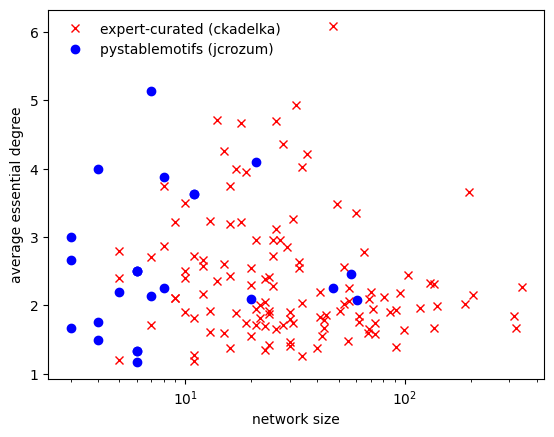

In [5]:
sizes_sm = [bn.N for bn in bns_sm]
average_degrees_sm = [np.mean(bn.indegrees) for bn in bns_sm]

f,ax = plt.subplots()
ax.semilogx(sizes,average_degrees,'rx',label = 'expert-curated (ckadelka)')
ax.semilogx(sizes_sm,average_degrees_sm,'bo',label = 'pystablemotifs (jcrozum)')
ax.set_xlabel('network size')
ax.set_ylabel('average essential degree')
ax.legend(loc='best',frameon=False);

## Null models

Observed properties of Boolean networks are often difficult to interpret in
isolation. For example, a network may exhibit a certain number of attractors,
a particular robustness to perturbations, or a specific Derrida value.
However, it is not immediately clear whether such properties are meaningful or
simply typical for networks with the same size and structural characteristics.

To address this question, researchers compare observed networks with
**null models**: randomly generated Boolean networks that preserve selected
structural features, such as the number of nodes, the wiring diagram, or the
bias of regulatory functions. By analyzing ensembles of such randomized
networks, it becomes possible to determine whether the behavior of a given
network is unusual or expected.

The BoolForge function `random_null_model(BooleanNetwork, *args)` provides 
extensive tools for generating these null models and for performing 
ensemble-based analyses that connect structural properties of Boolean functions
and networks with their dynamical behavior.

The function takes as required input a Boolean network. Important: This network
may not contain any degenerate update functions. If it does, these functions must
be simplified via `bn.simplify_functions()` prior to generating null models. 
The avoid repeating this step many times, this simplification is not performed 
inside `random_null_model`. The type of null model is specified by optional arguments. 
Both the wiring diagram and the Boolean update rules can be randomized subject 
to specified invariants.

### Randomization of the wiring diagram

By default, the wiring diagram of the provided Boolean network is not changed.
However, setting `wiring_diagram="fixed_indegree"` generates a new wiring
diagram using `random_wiring_diagram`. Each node in the new wiring diagram
has exactly the same in-degree as in the provided Boolean network.

In [6]:
bn_orig = bf.random_network(N=8, n=2, indegree_distribution='Poisson', rng = 3)

bn_null = bf.random_null_model(bn_orig, wiring_diagram='fixed_indegree')

print('bn_orig.in-degrees:',bn_orig.indegrees)
print('bn_null.in-degrees:',bn_null.indegrees)
print()
print('bn_orig.out-degrees:',bn_orig.outdegrees)
print('bn_null.out-degrees:',bn_null.outdegrees)

bn_orig.in-degrees: [1 2 1 2 1 2 3 2]
bn_null.in-degrees: [1 2 1 2 1 2 3 2]

bn_orig.out-degrees: [4 3 1 0 1 0 1 4]
bn_null.out-degrees: [2 2 1 3 0 1 3 2]


We see that the in-degrees of the original Boolean network are preserved,
while the out-degrees change substantially. Additional optional arguments
in the `fixed_indegree` mode include `strongly_connected`, `allow_self_loops`,
and `min_out_degree_one`, as described in detail in Tutorial 9.

A more constrained null model fixes the out-degree in addition to the
in-degree. This can be obtained by setting
`wiring_diagram="fixed_in_and_outdegree"`.

In [7]:
bn_orig = bf.random_network(N=8, n=2, indegree_distribution='Poisson', rng = 3)

bn_null = bf.random_null_model(bn_orig, wiring_diagram='fixed_in_and_outdegree')

print('bn_orig.in-degrees:',bn_orig.indegrees)
print('bn_null.in-degrees:',bn_null.indegrees)
print()
print('bn_orig.out-degrees:',bn_orig.outdegrees)
print('bn_null.out-degrees:',bn_null.outdegrees)

bn_orig.in-degrees: [1 2 1 2 1 2 3 2]
bn_null.in-degrees: [1 2 1 2 1 2 3 2]

bn_orig.out-degrees: [4 3 1 0 1 0 1 4]
bn_null.out-degrees: [4 3 1 0 1 0 1 4]


In the `fixed_in_and_outdegree` mode, the original wiring diagram is rewired
through an edge-swapping algorithm. Additional optional arguments that can
be used in this mode include `allow_new_self_loops` and
`allow_self_loop_rewiring`.

### Randomization of the update functions

In addition to the wiring diagram, the Boolean update functions can also be
randomized. This behavior is controlled by two Boolean flags:

- `preserve_bias`: If True (default), the newly generated update function of
  each node has the same Hamming weight (number of ones in the truth table) 
  as the original update function.

- `preserve_canalizing_depth`: If True (default), the newly generated update
  function of each node has the same canalizing depth as the original update
  function.

If both flags are True (the default), both properties are preserved
simultaneously. If neither flag is True, the newly generated update rules may
be any non-degenerate Boolean function consistent with the given in-degree.

In [8]:
# 8-node network governed by 3-input functions with minimum canalizing depth 1
bn_orig = bf.random_network(N=8, n=3, depth=1, rng = 6)

bn_null00 = bf.random_null_model(bn_orig, 
                                preserve_bias=False, 
                                preserve_canalizing_depth=False)
bn_null01 = bf.random_null_model(bn_orig, 
                                preserve_bias=False, 
                                preserve_canalizing_depth=True)
bn_null10 = bf.random_null_model(bn_orig, 
                                preserve_bias=True, 
                                preserve_canalizing_depth=False)
bn_null11 = bf.random_null_model(bn_orig, 
                                preserve_bias=True, 
                                preserve_canalizing_depth=True)

print('Canalizing depths:')
print('bn_orig:  ',
      [f.get_canalizing_depth() for f in bn_orig.F])
print('bn_null00:',
      [f.get_canalizing_depth() for f in bn_null00.F])
print('bn_null01:',
      [f.get_canalizing_depth() for f in bn_null01.F])
print('bn_null10:',
      [f.get_canalizing_depth() for f in bn_null10.F])
print('bn_null11:',
      [f.get_canalizing_depth() for f in bn_null11.F])
print()
print('Hamming weights:')

print('bn_orig:  ',
      [f.hamming_weight for f in bn_orig.F])
print('bn_null00:',
      [f.hamming_weight for f in bn_null00.F])
print('bn_null01:',
      [f.hamming_weight for f in bn_null01.F])
print('bn_null10:',
      [f.hamming_weight for f in bn_null10.F])
print('bn_null11:',
      [f.hamming_weight for f in bn_null11.F])

Canalizing depths:
bn_orig:   [3, 3, 1, 1, 3, 3, 1, 3]
bn_null00: [0, 3, 3, 0, 3, 3, 1, 0]
bn_null01: [3, 3, 1, 1, 3, 3, 1, 3]
bn_null10: [0, 0, 1, 1, 3, 0, 2, 3]
bn_null11: [3, 3, 1, 1, 3, 3, 1, 3]

Hamming weights:
bn_orig:   [3, 5, 6, 6, 1, 5, 2, 7]
bn_null00: [3, 7, 7, 5, 5, 3, 6, 3]
bn_null01: [5, 3, 2, 2, 7, 5, 2, 5]
bn_null10: [3, 5, 6, 6, 1, 5, 2, 7]
bn_null11: [3, 5, 6, 6, 1, 5, 2, 7]


We see that the preserved structural constraints determine which properties
of the original network are retained in the null models. Such controlled
randomization allows systematic investigation of how structural features
influence network dynamics.

## Example use case: high coherence of biological networks

As an example, we compare the *coherence* of curated biological Boolean
network models with the coherence expected under randomized null models.
Coherence measures the long-term resilience of a network to small perturbations.

For each biological network, we generate an ensemble of randomized null
models in which the wiring diagram is preserved but the Boolean update rules
are replaced by random Boolean functions. We then compare the coherence of the
biological model with the average coherence of its corresponding null models.


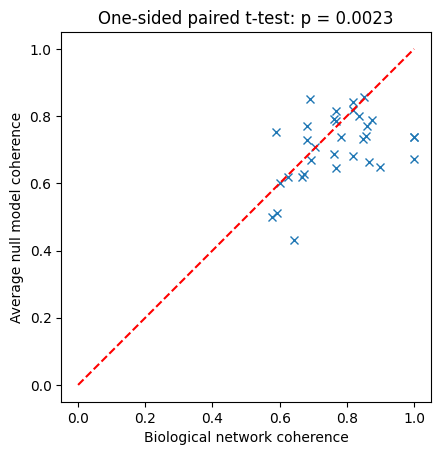

In [9]:
n_null_models = 50

bns_to_analyze = [bn for bn in bns if bn.N <= 16]
bio_data = [bn.get_attractors_and_robustness_synchronous_exact()['Coherence']
            for bn in bns_to_analyze]

null_data = []
for bn in bns_to_analyze:
    null_data.append([])
    for _ in range(n_null_models):
        null_model = bf.random_null_model(bn,
                                   preserve_bias=False,
                                   preserve_canalizing_depth=False)
        null_data[-1].append(
            null_model.get_attractors_and_robustness_synchronous_exact()['Coherence']
        )

f,ax = plt.subplots()
ax.plot(bio_data,np.mean(null_data,1),'x')
ax.plot([0,1],[0,1],'r--')
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Biological network coherence')
ax.set_ylabel('Average null model coherence')
stat, p = ttest_rel(bio_data,np.mean(null_data,1), alternative='greater')
p_str = f"{p:.2g}" if p >= 1e-3 else "< 0.001"
ax.set_title(f"One-sided paired t-test: p {('= ' if p >= 1e-3 else '')}{p_str}");

We see that most biological networks exhibit higher than expected coherence. 
Even for this small ensemble of biological networks (restricted here to
networks with at most 16 nodes to allow exact dynamical analysis), this
is a statistically significant difference, as exemplified by the one-sided paired t-test.

The higher coherence observed in biological networks is likely due to their highly biased 
and canalized regulatory logic. To test this, we can rerun the computational experiment, 
this time with null models where bias and/or canalizing depth are preserved.

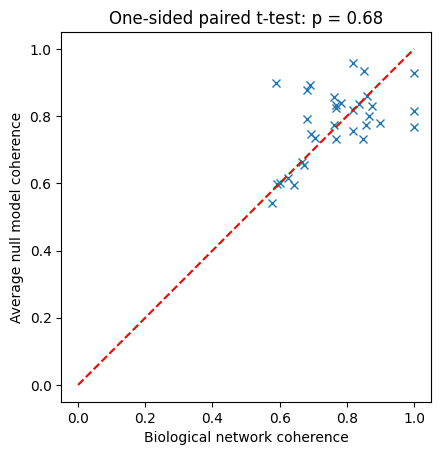

In [10]:
null_data = []
for i,bn in enumerate(bns_to_analyze):
    null_data.append([])
    for _ in range(n_null_models):
        null_model = bf.random_null_model(bn,
                                   preserve_bias=True,
                                   preserve_canalizing_depth=True)
        null_data[-1].append(
            null_model.get_attractors_and_robustness_synchronous_exact()['Coherence']
        )

f,ax = plt.subplots()
ax.plot(bio_data,np.mean(null_data,1),'x')
ax.plot([0,1],[0,1],'r--')
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Biological network coherence')
ax.set_ylabel('Average null model coherence');
stat, p = ttest_rel(bio_data,np.mean(null_data,1), alternative='greater')
p_str = f"{p:.2g}" if p >= 1e-3 else "< 0.001"
ax.set_title(f"One-sided paired t-test: p {('= ' if p >= 1e-3 else '')}{p_str}");

We observe that matching canalizing depth and bias (or just one of them, try it!)
suffices to eliminate the significant difference in coherence between
biological networks and their null models.

This illustrates how controlled null models can reveal which structural
properties of biological regulatory logic are responsible for observed
dynamical behavior.

## Summary

In this tutorial, we introduced **null models for Boolean networks** and
demonstrated how BoolForge can generate randomized networks while preserving
selected structural properties. Such null models provide a statistical
baseline that helps determine whether observed structural or dynamical
properties of a Boolean network are unusual or simply typical for networks
with similar characteristics.

We considered two main classes of null models:

- **Wiring diagram randomization**, where the regulatory graph is modified
  while preserving invariants such as node in-degrees or both in- and
  out-degrees.
- **Update function randomization**, where Boolean update rules are replaced
  by new functions that preserve properties such as bias or canalizing depth.

In addition, we demonstrated how Boolean network models can be **loaded from
biological model repositories** and analyzed using the same structural and
dynamical tools provided by BoolForge. This enables systematic investigation
of curated regulatory network models and comparison with appropriate null
models.

Together, these capabilities allow researchers to study how structural
features of regulatory networks influence their dynamical behavior and to
place biological models in the broader context of ensembles of randomized
networks.